# Class Imbalance Analysis in HAM10000

Skin lesion datasets such as HAM10000 exhibit significant class imbalance, 
where certain diagnostic categories dominate the dataset while others are severely underrepresented.

This imbalance can bias deep learning classifiers toward majority classes,
leading to poor sensitivity for rare but clinically important lesions.

This notebook:

1. Quantifies class imbalance in the training set
2. Visualizes distribution before augmentation
3. Measures imbalance severity using statistical indices
4. Motivates the need for GAN-based augmentation

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import sys
sys.path.insert(0, "..")
from configs.config import CLASSES

class_names = CLASSES

# Load train split
train_df = pd.read_csv("../dataset/splits/train.csv")

train_df.head()

,image_id,dx,label
0,ISIC_0027419,bkl,2
1,ISIC_0025030,bkl,2
2,ISIC_0026769,bkl,2
3,ISIC_0025661,bkl,2
4,ISIC_0031633,bkl,2


In [86]:
idx_to_class = {i: name for i, name in enumerate(class_names)}

train_df["label_name"] = train_df["label"].map(idx_to_class)

class_counts = train_df["label_name"].value_counts().sort_index()

print("Class Distribution (Train Set)")
print(class_counts)

Class Distribution (Train Set)
label_name
akiec     224
bcc       361
bkl       772
df         71
mel       773
nv       4682
vasc       99
Name: count, dtype: int64


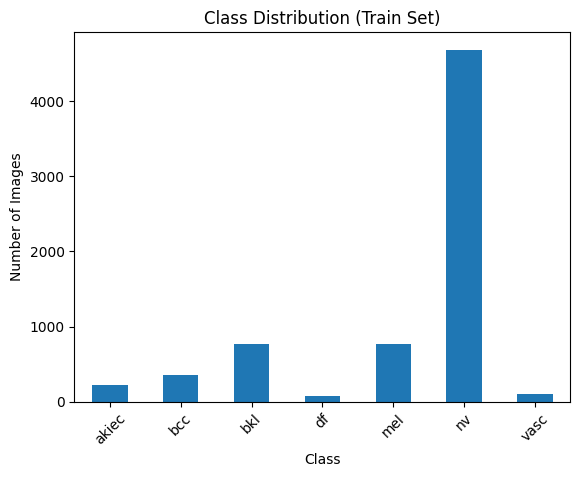

In [87]:
plt.figure()
class_counts.plot(kind="bar")
plt.title("Class Distribution (Train Set)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [88]:
total_samples = len(train_df)
percentage = (class_counts / total_samples) * 100

imbalance_df = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": percentage.round(2)
})

imbalance_df

,Count,Percentage (%)
label_name,,
akiec,224,3.21
bcc,361,5.17
bkl,772,11.06
df,71,1.02
mel,773,11.07
nv,4682,67.06
vasc,99,1.42


In [89]:
max_class = class_counts.max()
min_class = class_counts.min()

imbalance_ratio = max_class / min_class

print(f"Max class size: {max_class}")
print(f"Min class size: {min_class}")
print(f"Imbalance Ratio (IR): {imbalance_ratio:.2f}")

Max class size: 4682
Min class size: 71
Imbalance Ratio (IR): 65.94


In [90]:
def gini(array):
    array = np.sort(array)
    n = len(array)
    cumulative = np.cumsum(array)
    gini_index = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n
    return gini_index

gini_index = gini(class_counts.values)

print(f"Gini Coefficient: {gini_index:.4f}")

Gini Coefficient: 0.6437


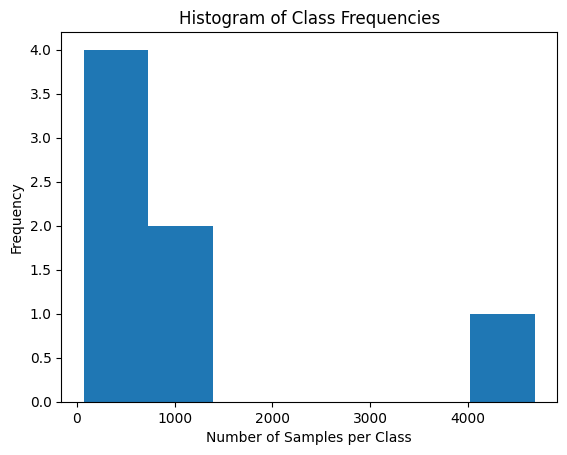

In [91]:
plt.figure()
plt.hist(class_counts.values, bins=len(class_counts))
plt.title("Histogram of Class Frequencies")
plt.xlabel("Number of Samples per Class")
plt.ylabel("Frequency")
plt.show()

### Observations

- The dataset exhibits significant imbalance across diagnostic categories.
- Minority classes (e.g., DF, VASC, AKIEC) contain substantially fewer samples 
  compared to majority classes (e.g., NV).
- The imbalance ratio indicates that the largest class contains several times 
  more samples than the smallest class.
- The Gini coefficient further confirms non-uniform distribution.

### Implications

Such imbalance may lead to:

- Reduced sensitivity for rare lesion types
- Bias toward majority classes
- Poor generalization for underrepresented categories

This motivates the application of GAN-based augmentation to improve minority class representation.

label
akiec    1183
bcc       361
bkl       772
df        920
mel       773
nv       4682
vasc     1249
Name: count, dtype: int64


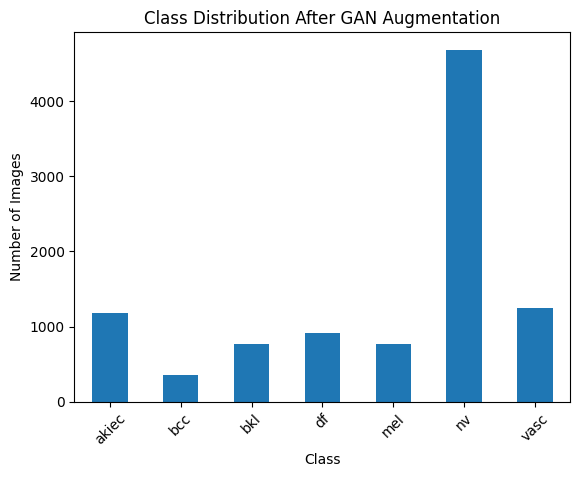

In [92]:
# Load synthetic
synthetic_df = pd.read_csv("../dataset/synthetic/synthetic_metadata.csv")

idx_to_class = {i: name for i, name in enumerate(class_names)}

# Convert train label (int -> string)
train_df["label"] = train_df["label"].map(idx_to_class)

# Concat
combined_df = pd.concat([train_df, synthetic_df])

# Count
combined_counts = combined_df["label"].value_counts().sort_index()

print(combined_counts)

# Plot
plt.figure()
combined_counts.plot(kind="bar")
plt.title("Class Distribution After GAN Augmentation")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()